<a href="https://colab.research.google.com/github/auzaluis/upsa_mod_202601/blob/main/forecasting/script_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Carga de datos**

In [ ]:
import pandas as pd
import plotly.express as px
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.formula.api import ols

In [ ]:
url = 'https://docs.google.com/spreadsheets/d/1sBrX_NAzXTXBYwsTKCw_bfm3LZdL3H3pYzmCHIX9JdQ/export?format=csv'

In [ ]:
df = pd.read_csv(url)
df.head()

,period,sales
0,1/1/2006,6455.898
1,2/1/2006,7036.648
2,3/1/2006,9383.576
3,4/1/2006,9160.716
4,5/1/2006,9500.516


**2. Preprocesado**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   period  125 non-null    object 
 1   sales   125 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.1+ KB


In [ ]:
df['period'] = pd.to_datetime(df['period'], format='%m/%d/%Y')
df.head()

,period,sales
0,2006-01-01,6455.898
1,2006-02-01,7036.648
2,2006-03-01,9383.576
3,2006-04-01,9160.716
4,2006-05-01,9500.516


In [ ]:
df_training = df[df['period'] <= '2015-12-01'].copy()
df_training

,period,sales
0,2006-01-01,6455.898
1,2006-02-01,7036.648
2,2006-03-01,9383.576
3,2006-04-01,9160.716
4,2006-05-01,9500.516
...,...,...
115,2015-08-01,21616.556
116,2015-09-01,20481.056
117,2015-10-01,21088.716
118,2015-11-01,19824.956


In [ ]:
# Descomposición de la serie
decomp = seasonal_decompose(
    df_training.set_index('period')['sales'],
    period=12
)

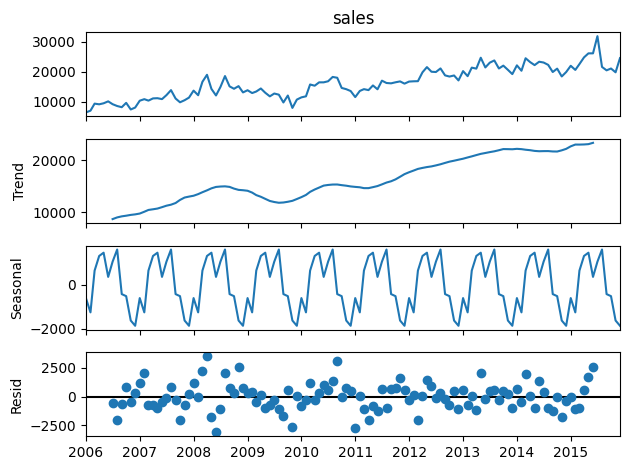

In [ ]:
decomp.plot();

**3. Entrenamiento del modelo**

In [ ]:
df_model = df_training.copy()

Features

In [ ]:
df_model['trend'] = range(1, len(df_model) + 1)

In [ ]:
df_model.head()

,period,sales,trend
0,2006-01-01,6455.898,1
1,2006-02-01,7036.648,2
2,2006-03-01,9383.576,3
3,2006-04-01,9160.716,4
4,2006-05-01,9500.516,5


In [ ]:
# Modelo de regresión
model = ols(
    formula='sales ~ trend',
    data=df_model
).fit()

In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.792
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     448.3
Date:                Sat, 09 May 2026   Prob (F-statistic):           5.30e-42
Time:                        12:46:30   Log-Likelihood:                -1100.0
No. Observations:                 120   AIC:                             2204.
Df Residuals:                     118   BIC:                             2210.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   8368.3003    429.279     19.494      0.0